In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("C:/Users/Paula/OneDrive/Documentos/8 SEMESTRE/CIENCIA DE DATOS II/WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
variables = [
    'fixed acidity',
    'volatile acidity',
    'citric acid',
    'residual sugar',
    'chlorides',
    'free sulfur dioxide',
    'total sulfur dioxide',
    'density',
    'pH',
    'alcohol'
]

X = df[variables]

X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,9.4


In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA())
])

X_pca = pipeline.fit_transform(X)

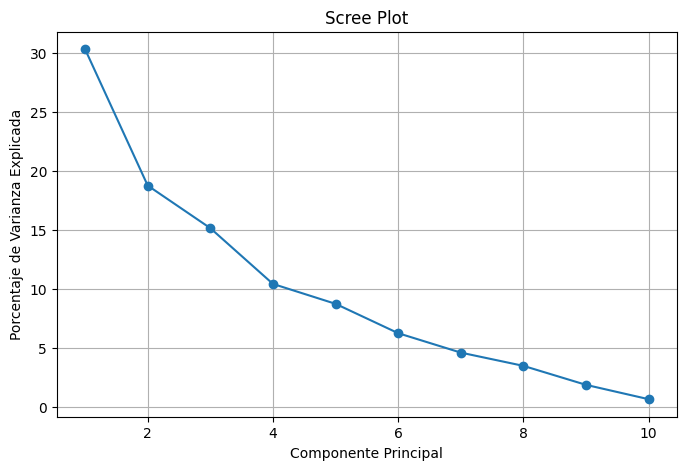

In [6]:
evr = pipeline.named_steps["pca"].explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(evr)+1),
    100 * evr,
    marker='o'
)

plt.xlabel("Componente Principal")
plt.ylabel("Porcentaje de Varianza Explicada")
plt.title("Scree Plot")

plt.grid()
plt.show()

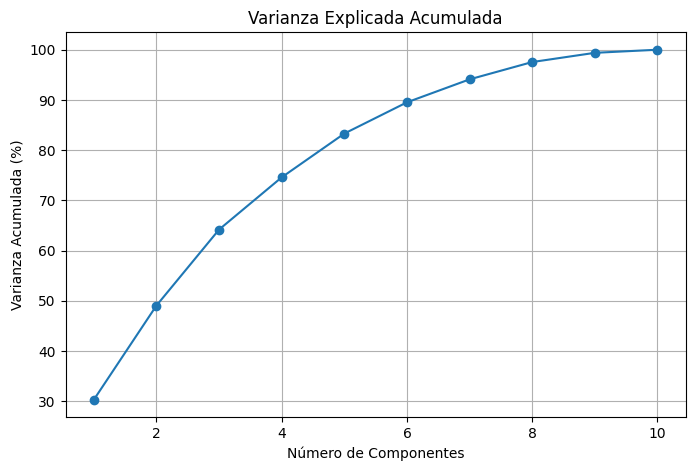

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(evr)+1),
    np.cumsum(evr)*100,
    marker='o'
)

plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada (%)")
plt.title("Varianza Explicada Acumulada")

plt.grid()
plt.show()

In [8]:
pca_2 = PCA(n_components=2)

X_2d = pca_2.fit_transform(X_scaled)

X_2d[:5]

array([[-1.40179396,  0.38228006],
       [-0.75315715,  1.90803552],
       [-0.66394612,  0.88620358],
       [ 2.47818728, -0.30351229],
       [-1.40179396,  0.38228006]])

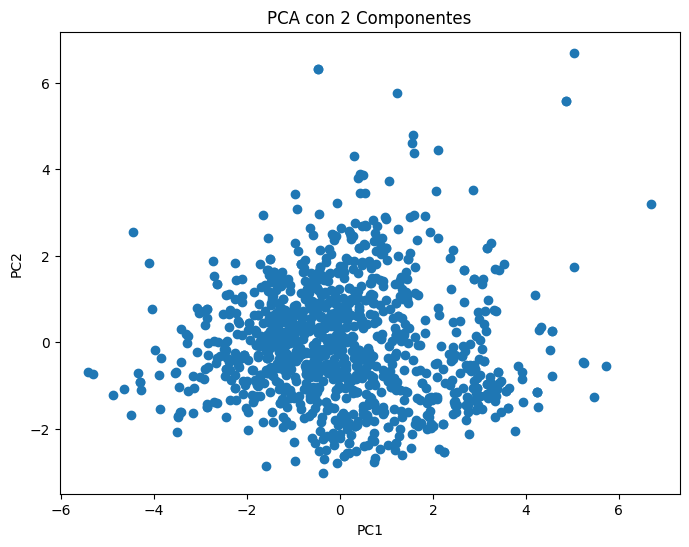

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA con 2 Componentes")

plt.show()

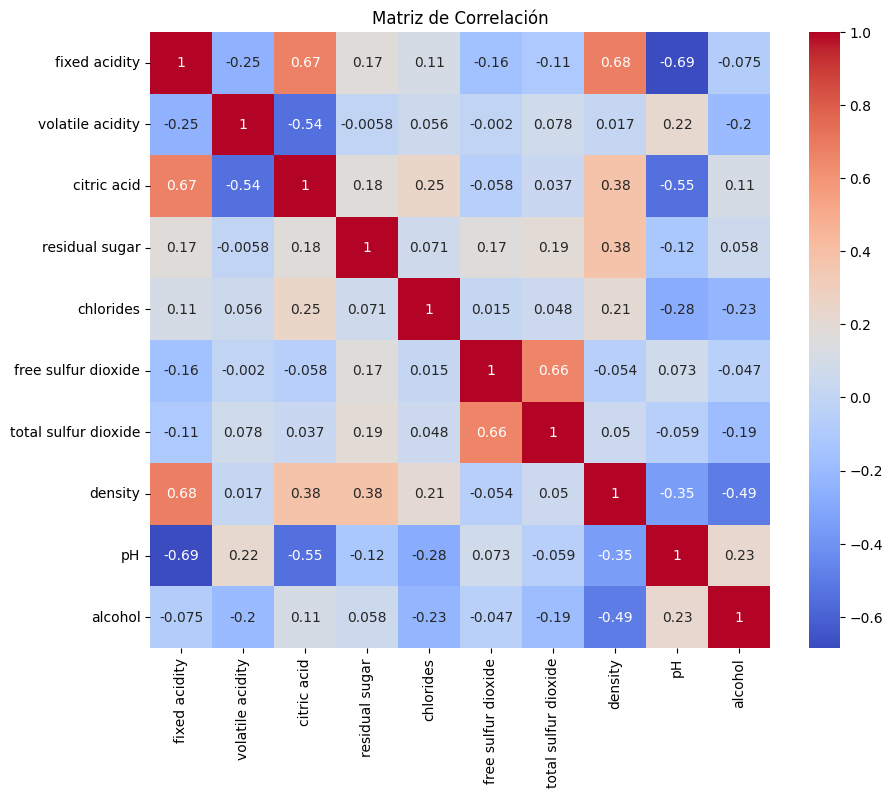

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de Correlación")

plt.show()

In [11]:
X_selected = X.drop(columns=[
    'density',
    'free sulfur dioxide'
])

In [12]:
scaler = StandardScaler()

X_selected_scaled = scaler.fit_transform(X_selected)

In [13]:
def evaluar_kmeans(data, nombre_dataset):

    inercias = []
    silhouette_scores = []

    k_values = range(2,7)

    for k in k_values:

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(data)

        inercias.append(kmeans.inertia_)

        silhouette_scores.append(
            silhouette_score(data, labels)
        )

    # Método del codo
    plt.figure(figsize=(7,4))

    plt.plot(k_values, inercias, marker='o')

    plt.xlabel("Número de clusters")
    plt.ylabel("Inercia")
    plt.title(f"Método del Codo - {nombre_dataset}")

    plt.show()

    # Silhouette score
    plt.figure(figsize=(7,4))

    plt.plot(k_values, silhouette_scores, marker='o')

    plt.xlabel("Número de clusters")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Score - {nombre_dataset}")

    plt.show()

    # Mostrar resultados
    resultados = pd.DataFrame({
        "K": list(k_values),
        "Silhouette": silhouette_scores
    })

    return resultados

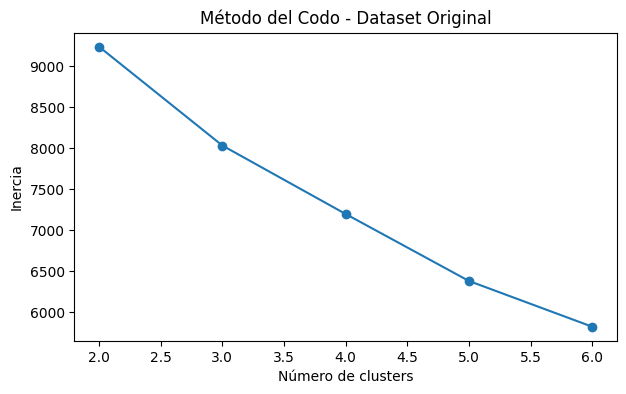

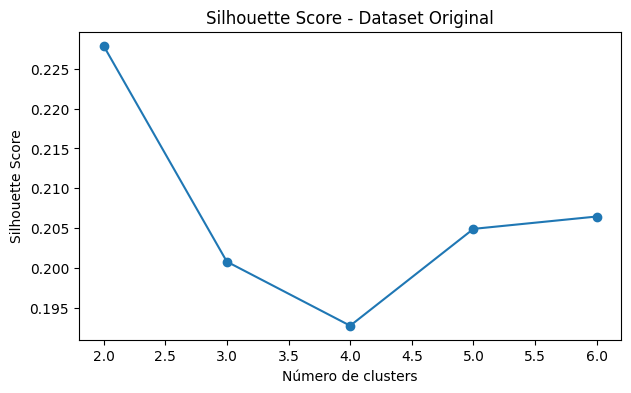

,K,Silhouette
0,2,0.227898
1,3,0.200792
2,4,0.192750
3,5,0.204907
4,6,0.206459


In [14]:
resultados_original = evaluar_kmeans(
    X_scaled,
    "Dataset Original"
)

resultados_original

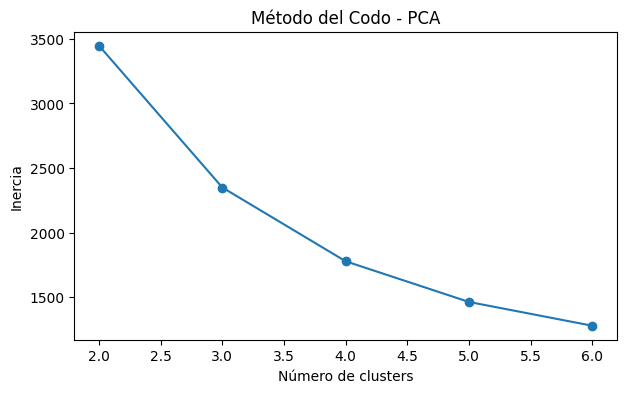

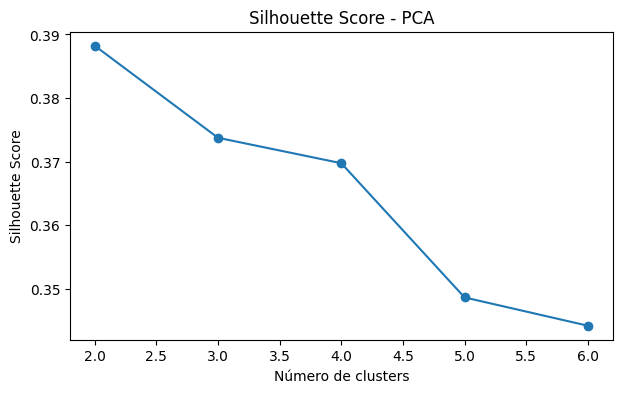

,K,Silhouette
0,2,0.388234
1,3,0.373766
2,4,0.369769
3,5,0.348672
4,6,0.344225


In [15]:
resultados_pca = evaluar_kmeans(
    X_2d,
    "PCA"
)

resultados_pca

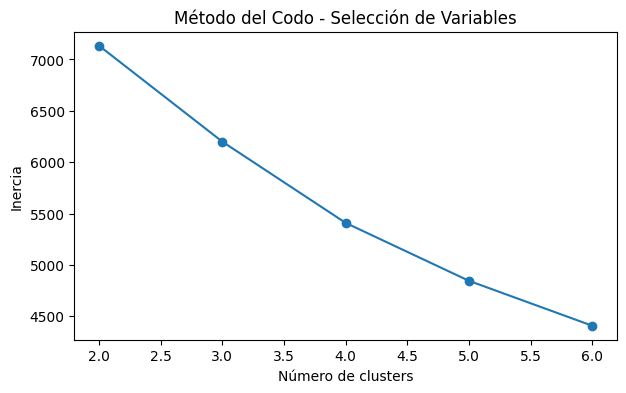

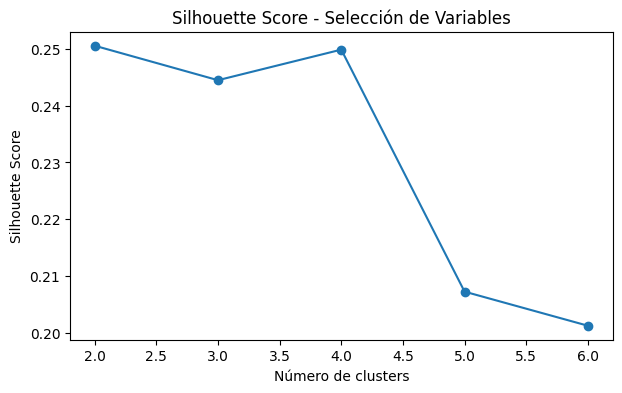

,K,Silhouette
0,2,0.250546
1,3,0.244476
2,4,0.249858
3,5,0.207251
4,6,0.201254


In [16]:
resultados_selected = evaluar_kmeans(
    X_selected_scaled,
    "Selección de Variables"
)

resultados_selected

In [17]:
comparacion = pd.DataFrame({

    "Dataset": [
        "Original",
        "PCA",
        "Selección Variables"
    ],

    "Mejor Silhouette": [
        resultados_original["Silhouette"].max(),
        resultados_pca["Silhouette"].max(),
        resultados_selected["Silhouette"].max()
    ]
})

comparacion

,Dataset,Mejor Silhouette
0,Original,0.227898
1,PCA,0.388234
2,Selección Variables,0.250546
